In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/turkishCF.csv', sep=';')
df.head()

,id,platform_adi,kitle_fonlamasi_turu,kategori,fon_sekli,proje_adi,proje_sahibi,proje_sahibi_cinsiyet,kac_proje_destekledi,kac_projeye_abone,kac_projenin_sahibi,kac_proje_takiminda,konum,bolge,yil,proje_baslama_tarihi,proje_bitis_tarihi,gun_sayisi,tanitim_videosu,video_uzunlugu,gorsel_sayisi,sss,guncellemeler,yorumlar,destekci_sayisi,odul_sayisi,ekip_kisi_sayisi,web_sitesi,sosyal_medya,sm_sayisi,sm_takipci,etiket_sayisi,icerik_kelime_sayisi,proje_aciklamasi,hedef_miktari,toplanan_tutar,destek_orani,basari_durumu
0,1,fongogo,ödül,diğer,ya hep ya hiç,Gerçek Gizlidir Filmleri,Lob Ekibi,belirsiz,1,0,1,0,istanbul,marmara,2014,15.09.2014,16.11.2014,62,var,104,1,0,4,0,150,11,4,yok,var,3,274,0,301,Türkiye’de ilk kez her aşaması ‘online’ olarak...,40000,54410,136%,başarılı
1,2,fongogo,ödül,diğer,ya hep ya hiç,Fongogo - Hayat Bulsun!,Fongogo Team,belirsiz,3,0,2,0,istanbul,marmara,2015,4.05.2015,3.07.2015,60,yok,0,12,0,0,0,51,11,7,yok,var,3,5634,0,167,"Fongogo ekibi olarak büyümek, daha geniş kitle...",50000,50110,100%,başarılı
2,3,fongogo,ödül,diğer,ya hep ya hiç,"PAYLAŞIMIN, SEVGİNİN VE ÇOCUKLARIN İYİLİK EVİ ...",SİNEM CAN,kadın,0,0,2,1,belirsiz,belirsiz,2017,NaN,13.06.2017,60,var,60,8,1,1,1,25,6,2,var,var,2,510,4,413,Çocuklara her şeyin ücretsiz olduğu iyilik evi...,47000,47850,101%,başarılı
3,4,fongogo,ödül,diğer,ya hep ya hiç,Türk Kadının 100.yıl Seyri,Deniz Tutkusu Seyirde,kadın,0,0,1,0,muğla,ege,2019,19.04.2019,18.06.2019,60,var,67,6,0,0,0,45,7,1,var,var,2,3338,5,287,‘Sözde değil Özde İzindeyiz ‘ sloganıyla Atatü...,35000,35450,101%,başarılı
4,5,fongogo,ödül,diğer,ya hep ya hiç,Doğadaki Çocuk,Seren Kutadgu,kadın,2,0,1,0,istanbul,marmara,2019,2.09.2019,1.11.2019,60,var,149,5,0,0,0,105,8,6,yok,var,1,144,3,571,İstanbul'daki çocuk yuvalarında yaşayan dezava...,30000,31250,104%,başarılı


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1628 entries, 0 to 1627
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     1628 non-null   int64 
 1   platform_adi           1628 non-null   object
 2   kitle_fonlamasi_turu   1628 non-null   object
 3   kategori               1628 non-null   object
 4   fon_sekli              1628 non-null   object
 5   proje_adi              1628 non-null   object
 6   proje_sahibi           1628 non-null   object
 7   proje_sahibi_cinsiyet  1628 non-null   object
 8   kac_proje_destekledi   1628 non-null   int64 
 9   kac_projeye_abone      1628 non-null   int64 
 10  kac_projenin_sahibi    1628 non-null   int64 
 11  kac_proje_takiminda    1628 non-null   int64 
 12  konum                  1628 non-null   object
 13  bolge                  1627 non-null   object
 14  yil                    1628 non-null   int64 
 15  proje_baslama_tarihi 

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1628.0,814.500000,470.107435,1.0,407.75,814.5,1221.25,1628.0
kac_proje_destekledi,1628.0,0.429361,2.225029,0.0,0.00,0.0,0.00,31.0
kac_projeye_abone,1628.0,0.000614,0.024784,0.0,0.00,0.0,0.00,1.0
kac_projenin_sahibi,1628.0,1.165848,0.710455,1.0,1.00,1.0,1.00,7.0
kac_proje_takiminda,1628.0,0.052826,0.244744,0.0,0.00,0.0,0.00,4.0
yil,1628.0,2018.042383,2.054583,2011.0,2017.00,2019.0,2020.00,2021.0
gun_sayisi,1628.0,52.004914,15.294526,0.0,45.00,60.0,60.00,118.0
video_uzunlugu,1628.0,67.668305,108.145452,0.0,0.00,46.0,98.25,1651.0
gorsel_sayisi,1628.0,5.036855,7.842166,0.0,1.00,3.0,7.00,221.0
sss,1628.0,0.203317,1.439136,0.0,0.00,0.0,0.00,30.0


In [ ]:
df_kolayi = df.T
print(df_kolayi)

                                                                    0     ...                                               1627
id                                                                     1  ...                                               1628
platform_adi                                                     fongogo  ...                                            buluşum
kitle_fonlamasi_turu                                                ödül  ...                                               ödül
kategori                                                           diğer  ...                                       kültür-sanat
fon_sekli                                                  ya hep ya hiç  ...                                      ya hep ya hiç
proje_adi                                       Gerçek Gizlidir Filmleri  ...                       Bikes vs Cars Film Gösterimi
proje_sahibi                                                   Lob Ekibi  ...                    

In [ ]:
df_kopya = df.copy()

In [ ]:
print("Toplam eksik veri: ", df.isnull().sum())

Toplam eksik veri:  id                         0
platform_adi               0
kitle_fonlamasi_turu       0
kategori                   0
fon_sekli                  0
proje_adi                  0
proje_sahibi               0
proje_sahibi_cinsiyet      0
kac_proje_destekledi       0
kac_projeye_abone          0
kac_projenin_sahibi        0
kac_proje_takiminda        0
konum                      0
bolge                      1
yil                        0
proje_baslama_tarihi     611
proje_bitis_tarihi       553
gun_sayisi                 0
tanitim_videosu            0
video_uzunlugu             0
gorsel_sayisi              0
sss                        0
guncellemeler              0
yorumlar                   0
destekci_sayisi            0
odul_sayisi                0
ekip_kisi_sayisi           0
web_sitesi                 0
sosyal_medya               0
sm_sayisi                  0
sm_takipci                 0
etiket_sayisi              0
icerik_kelime_sayisi       0
proje_aciklamasi       

In [ ]:
df.dropna(subset=['proje_baslama_tarihi'], inplace=True)
print("Kalan eksik veriler: ", df.isnull().sum())

Kalan eksik veriler:  id                       0
platform_adi             0
kitle_fonlamasi_turu     0
kategori                 0
fon_sekli                0
proje_adi                0
proje_sahibi             0
proje_sahibi_cinsiyet    0
kac_proje_destekledi     0
kac_projeye_abone        0
kac_projenin_sahibi      0
kac_proje_takiminda      0
konum                    0
bolge                    1
yil                      0
proje_baslama_tarihi     0
proje_bitis_tarihi       0
gun_sayisi               0
tanitim_videosu          0
video_uzunlugu           0
gorsel_sayisi            0
sss                      0
guncellemeler            0
yorumlar                 0
destekci_sayisi          0
odul_sayisi              0
ekip_kisi_sayisi         0
web_sitesi               0
sosyal_medya             0
sm_sayisi                0
sm_takipci               0
etiket_sayisi            0
icerik_kelime_sayisi     0
proje_aciklamasi         0
hedef_miktari            0
toplanan_tutar           0
destek

In [ ]:
df.dropna(subset = ['proje_bitis_tarihi'], inplace = True)
print("Proje başlama tarihi ve proje bitiş tarihi olmayan projeleri görelim: ", df.isnull().sum())

Proje başlama tarihi ve proje bitiş tarihi olmayan projeleri görelim:  id                       0
platform_adi             0
kitle_fonlamasi_turu     0
kategori                 0
fon_sekli                0
proje_adi                0
proje_sahibi             0
proje_sahibi_cinsiyet    0
kac_proje_destekledi     0
kac_projeye_abone        0
kac_projenin_sahibi      0
kac_proje_takiminda      0
konum                    0
bolge                    1
yil                      0
proje_baslama_tarihi     0
proje_bitis_tarihi       0
gun_sayisi               0
tanitim_videosu          0
video_uzunlugu           0
gorsel_sayisi            0
sss                      0
guncellemeler            0
yorumlar                 0
destekci_sayisi          0
odul_sayisi              0
ekip_kisi_sayisi         0
web_sitesi               0
sosyal_medya             0
sm_sayisi                0
sm_takipci               0
etiket_sayisi            0
icerik_kelime_sayisi     0
proje_aciklamasi         0
hedef_mikta

In [ ]:
df.dropna(subset = ['bolge'], inplace = True)
print("Artık eksik verisi olmayan projeler: ", df.isnull().sum())

Artık eksik verisi olmayan projeler:  id                       0
platform_adi             0
kitle_fonlamasi_turu     0
kategori                 0
fon_sekli                0
proje_adi                0
proje_sahibi             0
proje_sahibi_cinsiyet    0
kac_proje_destekledi     0
kac_projeye_abone        0
kac_projenin_sahibi      0
kac_proje_takiminda      0
konum                    0
bolge                    0
yil                      0
proje_baslama_tarihi     0
proje_bitis_tarihi       0
gun_sayisi               0
tanitim_videosu          0
video_uzunlugu           0
gorsel_sayisi            0
sss                      0
guncellemeler            0
yorumlar                 0
destekci_sayisi          0
odul_sayisi              0
ekip_kisi_sayisi         0
web_sitesi               0
sosyal_medya             0
sm_sayisi                0
sm_takipci               0
etiket_sayisi            0
icerik_kelime_sayisi     0
proje_aciklamasi         0
hedef_miktari            0
toplanan_tutar   

In [ ]:
print("Veri boyutu: ", df.shape)
print("Kalan eksik değer sayısı: ", df.isnull().sum())
print("Dönüşüm için sütun türlerini görelim: ", df.dtypes)

Veri boyutu:  (1016, 38)
Kalan eksik değer sayısı:  id                       0
platform_adi             0
kitle_fonlamasi_turu     0
kategori                 0
fon_sekli                0
proje_adi                0
proje_sahibi             0
proje_sahibi_cinsiyet    0
kac_proje_destekledi     0
kac_projeye_abone        0
kac_projenin_sahibi      0
kac_proje_takiminda      0
konum                    0
bolge                    0
yil                      0
proje_baslama_tarihi     0
proje_bitis_tarihi       0
gun_sayisi               0
tanitim_videosu          0
video_uzunlugu           0
gorsel_sayisi            0
sss                      0
guncellemeler            0
yorumlar                 0
destekci_sayisi          0
odul_sayisi              0
ekip_kisi_sayisi         0
web_sitesi               0
sosyal_medya             0
sm_sayisi                0
sm_takipci               0
etiket_sayisi            0
icerik_kelime_sayisi     0
proje_aciklamasi         0
hedef_miktari            0
top

In [ ]:

df['proje_baslama_tarihi'] = pd.to_datetime(df['proje_baslama_tarihi'], format='mixed', dayfirst=True, errors='coerce')
df['proje_bitis_tarihi'] = pd.to_datetime(df['proje_bitis_tarihi'], format='mixed', dayfirst=True, errors='coerce')
print("Tarih sütunlarının güncel türleri:")
print(df[['proje_baslama_tarihi', 'proje_bitis_tarihi']].dtypes)

Tarih sütunlarının güncel türleri:
proje_baslama_tarihi    datetime64[ns]
proje_bitis_tarihi      datetime64[ns]
dtype: object


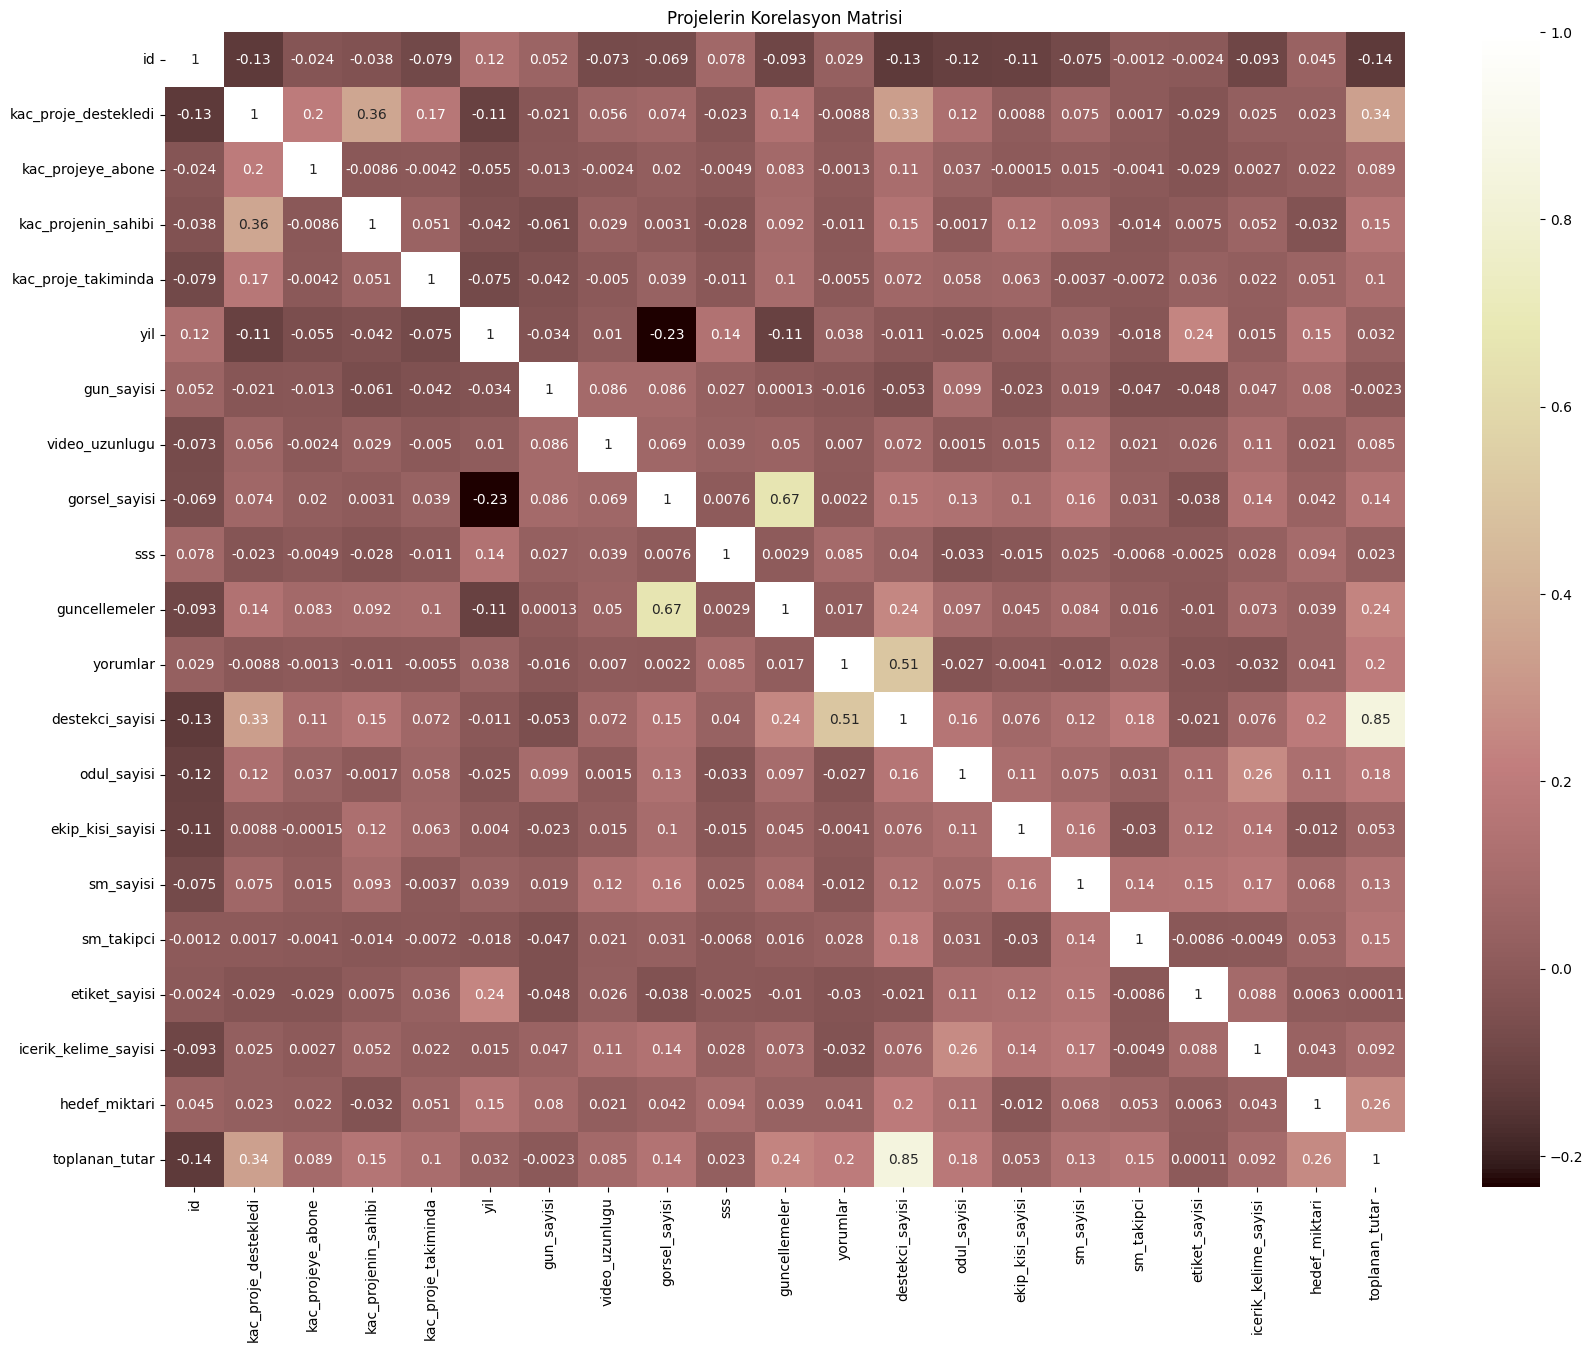

In [ ]:
#Korelasyon Matrisi
plt.figure(figsize=(20, 15))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='pink')
plt.title('Projelerin Korelasyon Matrisi')
plt.show()

In [ ]:
target = 'yil'
corr_with_target = corr[target].sort_values(ascending = True)
print('Yıla Göre Korelasyonlar')
print(corr_with_target)

Yıla Göre Korelasyonlar
gorsel_sayisi          -0.233187
kac_proje_destekledi   -0.110621
guncellemeler          -0.109340
kac_proje_takiminda    -0.075128
kac_projeye_abone      -0.055043
kac_projenin_sahibi    -0.042088
gun_sayisi             -0.034043
odul_sayisi            -0.024500
sm_takipci             -0.018040
destekci_sayisi        -0.010731
ekip_kisi_sayisi        0.003954
video_uzunlugu          0.010006
icerik_kelime_sayisi    0.014983
toplanan_tutar          0.032397
yorumlar                0.037725
sm_sayisi               0.038667
id                      0.119008
sss                     0.142432
hedef_miktari           0.152061
etiket_sayisi           0.241146
yil                     1.000000
Name: yil, dtype: float64


Text(0.5, 1.0, 'yil Dağılımı')

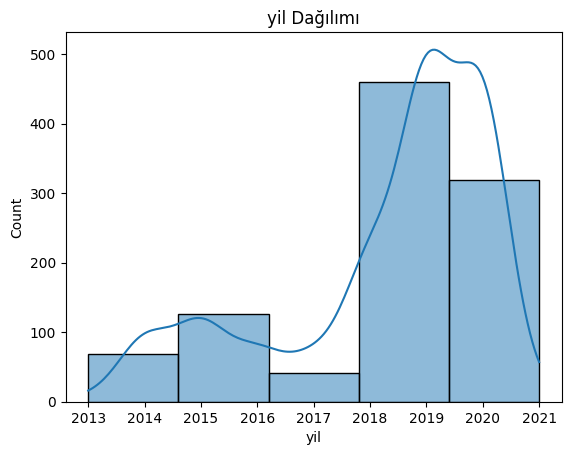

In [ ]:
sns.histplot(df[target], bins = 5, kde= True)
plt.title(f'{target} Dağılımı')

In [ ]:
target_2 = 'toplanan_tutar'
corr_with_target_2 = corr[target_2].sort_values(ascending = False)
print('Toplanan Tutara Göre Korelasyonlar')
print(corr_with_target_2)


Toplanan Tutara Göre Korelasyonlar
toplanan_tutar          1.000000
destekci_sayisi         0.846733
kac_proje_destekledi    0.338150
hedef_miktari           0.257927
guncellemeler           0.237988
yorumlar                0.197344
odul_sayisi             0.176715
kac_projenin_sahibi     0.153902
sm_takipci              0.153692
gorsel_sayisi           0.144843
sm_sayisi               0.133522
kac_proje_takiminda     0.104757
icerik_kelime_sayisi    0.091808
kac_projeye_abone       0.088635
video_uzunlugu          0.084684
ekip_kisi_sayisi        0.052796
yil                     0.032397
sss                     0.022983
etiket_sayisi           0.000111
gun_sayisi             -0.002308
id                     -0.135380
Name: toplanan_tutar, dtype: float64


Text(0.5, 1.0, 'toplanan_tutar Dağılımı')

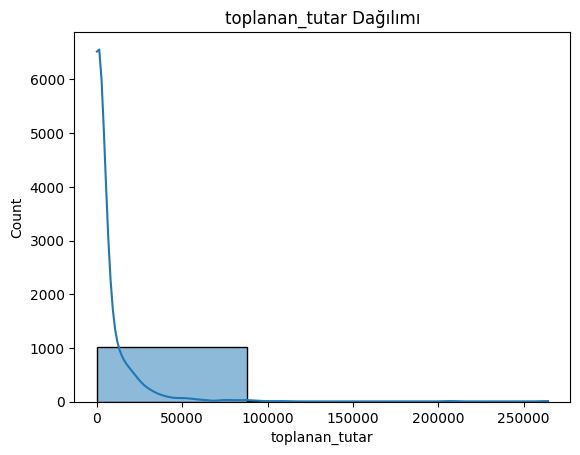

In [ ]:
sns.histplot(df[target_2], bins = 3, kde = True)
plt.title(f'{target_2} Dağılımı')

In [ ]:

X_simple = df['sm_sayisi'].values.reshape(-1, 1)

y_modified = df['sm_takipci'].copy()
sm_sayisi_values = df['sm_sayisi']

mask_ge_2 = sm_sayisi_values >= 2
y_modified.loc[mask_ge_2] += 100

mask_gt_2 = sm_sayisi_values > 2
y_modified.loc[mask_gt_2] += (sm_sayisi_values.loc[mask_gt_2] - 2) * 65

y = y_modified.values.reshape(-1, 1)

#Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)
print(f'Eğitim verisi boyutu: {X_train.shape[0]}')
print(f'Test verisi boyutu: {X_test.shape[0]}')

Eğitim verisi boyutu: 812
Test verisi boyutu: 204


In [ ]:
# Modeli oluştur ve eğit

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_train = model_simple.predict(X_train)
y_pred_test = model_simple.predict(X_test)

beta_0 = model_simple.intercept_[0]
beta_1 = model_simple.coef_[0][0]

print(f'Kesim Noktası (β₀): {beta_0:.4f}')
print(f'Eğim (β₁): {beta_1:.4f}')
print(f'Model Denklemi:')
print(f'sm_takipci = {beta_0:.4f} + {beta_1:.4f} × sm_sayisi')

In [ ]:
# Tahmin vs gerçek değerler (test seti)

results = pd.DataFrame({
    'Gerçek Sm Takipci': y_test.flatten(),
    'Tahmin Edilen Sm Takipci': y_pred_test.flatten(),
    'Fark': (y_test - y_pred_test).flatten()
})
results.index = df.iloc[X_test.flatten().argsort()[:len(y_test)]]['id'].values if len(y_test) <= 5 else None
print('Test Seti Tahminleri:')
print(results)

In [ ]:
# Model performans metrikleri

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

metrics = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train:.3f}', f'{mae_train:.3f}', f'{r2_train:.3f}'],
    'Test': [f'{rmse_test:.3f}', f'{mae_test:.3f}', f'{r2_test:.3f}']
})
print('Model Performansı:')
print(metrics.to_string(index=False))

In [ ]:
# Görselleştirme: Regresyon doğrusu

plt.figure(figsize=(10, 6))

plt.scatter(X_simple, y, color='blue', alpha=0.6, label='Gerçek Veri', s=80)

x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
y_line = model_simple.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regresyon Doğrusu: y = {beta_0:.2f} + {beta_1:.2f}x')

plt.xlabel('SM Sayısı (Sosyal Medya Sayısı)')
plt.ylabel('SM Takipçi (Sosyal Medya Takipçi Sayısı)')
plt.title('Basit Doğrusal Regresyon: SM Sayısı → SM Takipçi Sayısı')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Artık (Residual) analizi
residuals = y_test - y_pred_test

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.7, s=60)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Artık (Residual)')
plt.title('Artık Grafiği (Heteroskedastisite Kontrolü)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=5, kde=True)
plt.xlabel('Artık')
plt.title('Artık Dağılımı (Normallik Kontrolü)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Artıkların ortalaması: {np.mean(residuals):.4f}')
print(f'Artıkların standart sapması: {np.std(residuals):.4f}')